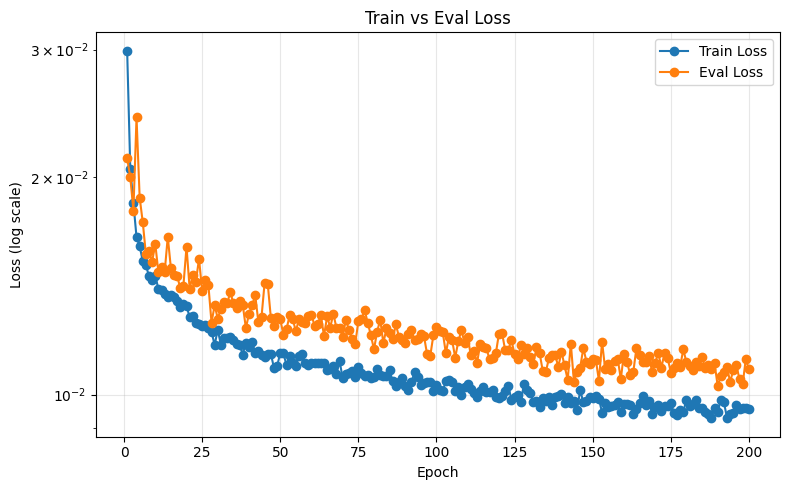

In [13]:
import json
import matplotlib.pyplot as plt

with open("training_log_recurrent_confidence_closed_rooms_C24.json") as f:
    data = json.load(f)

#data = data[10:]
epochs = [d["epoch"] for d in data]
train_losses = [d["train_loss"] for d in data]
eval_losses = [d["eval_loss"] for d in data]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_losses, marker="o", label="Train Loss")
ax.plot(epochs, eval_losses, marker="o", label="Eval Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Train vs Eval Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


CSV_PATHS = [
    "eval_metrics_garden/evaluation_metrics_unet_train_garden_eval_garden.csv",
    
    "eval_metrics_garden/evaluation_metrics_recurrent_no_conf_train_garden_eval_garden.csv",
    "eval_metrics_garden/evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_garden.csv",
    
    "eval_metrics_garden/evaluation_metrics_recurrent_conf_train_garden_eval_garden.csv",
    "eval_metrics_garden/evaluation_metrics_recurrent_conf_train_closed_rooms_eval_garden.csv",
    
    
    
    "eval_metrics_kitchen/evaluation_metrics_unet_train_garden_eval_kitchen.csv",
    
    "eval_metrics_kitchen/evaluation_metrics_recurrent_no_conf_train_garden_eval_kitchen.csv",
    "eval_metrics_kitchen/evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_kitchen.csv",
    
    "eval_metrics_kitchen/evaluation_metrics_recurrent_conf_train_garden_eval_kitchen.csv",
    "eval_metrics_kitchen/evaluation_metrics_recurrent_conf_train_closed_rooms_eval_kitchen.csv",
]



CSV_NAME_MAP = {
    "evaluation_metrics_unet_train_garden_eval_garden": {
        "model": "U-Net",
        "dataset": "Garden",
        "eval_set": "Garden",
    },
    
    "evaluation_metrics_recurrent_no_conf_train_garden_eval_garden": {
        "model": "Recurrent",
        "dataset": "Garden",
        "eval_set": "Garden",
    },
    "evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_garden": {
        "model": "Recurrent",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Garden",
    },
    
    "evaluation_metrics_recurrent_conf_train_garden_eval_garden": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden",
        "eval_set": "Garden",
    },
    "evaluation_metrics_recurrent_conf_train_closed_rooms_eval_garden": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Garden",
    },
    
    
    
    "evaluation_metrics_unet_train_garden_eval_kitchen": {
        "model": "U-Net",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    
    "evaluation_metrics_recurrent_no_conf_train_garden_eval_kitchen": {
        "model": "Recurrent",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    "evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_kitchen": {
        "model": "Recurrent",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Kitchen",
    },
    
    "evaluation_metrics_recurrent_conf_train_garden_eval_kitchen": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    "evaluation_metrics_recurrent_conf_train_closed_rooms_eval_kitchen": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Kitchen",
    },
}


def infer_names_from_csv_path(csv_path: str) -> tuple[str, str, str]:
    csv_stem = Path(csv_path).stem

    if csv_stem in CSV_NAME_MAP:
        return (
            CSV_NAME_MAP[csv_stem]["model"],
            CSV_NAME_MAP[csv_stem]["dataset"],
            CSV_NAME_MAP[csv_stem]["eval_set"],
        )

    return csv_stem, csv_stem, csv_stem


def load_metrics_table(csv_paths):
    rows = []

    metric_cols = [
        "mean_rmse",
        "mean_ssim",
    ]

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        model_name, dataset_name, eval_set_name = infer_names_from_csv_path(csv_path)

        for _, row in df.iterrows():
            output_row = {
                "Model": model_name,
                "Training Dataset": dataset_name,
                "Evaluation Dataset": eval_set_name,
            }

            for col in metric_cols:
                if col in df.columns:
                    output_row[col] = row[col]
                else:
                    output_row[col] = None

            rows.append(output_row)

    return pd.DataFrame(rows)


table_df = load_metrics_table(CSV_PATHS)

table_df = table_df.rename(columns={
    "mean_rmse": "RMSE",
    "mean_ssim": "SSIM",
})

numeric_cols = table_df.select_dtypes(include="number").columns
table_df[numeric_cols] = table_df[numeric_cols].round(6)


latex_table = table_df.to_latex(
    index=False,
    escape=False,
    float_format="%.6f",
    caption="Evaluation metrics for different models, training datasets, and evaluation datasets.",
    label="tab:evaluation_metric_results",
)

print(latex_table)

output_path = "evaluation_metrics_table.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to: {output_path}")

\begin{table}
\caption{Evaluation metrics for different models, training datasets, and evaluation datasets.}
\label{tab:evaluation_metric_results}
\begin{tabular}{lllrr}
\toprule
Model & Training Dataset & Evaluation Dataset & RMSE & SSIM \\
\midrule
U-Net & Garden & Garden & 0.066580 & 0.623725 \\
Recurrent & Garden & Garden & 0.054047 & 0.703935 \\
Recurrent & Garden + Gym + Office & Garden & 0.054202 & 0.696430 \\
Recurrent + Conf. & Garden & Garden & 0.055749 & 0.694458 \\
Recurrent + Conf. & Garden + Gym + Office & Garden & 0.082186 & 0.652743 \\
U-Net & Garden & Kitchen & 0.036869 & 0.870538 \\
Recurrent & Garden & Kitchen & 0.029394 & 0.894751 \\
Recurrent & Garden + Gym + Office & Kitchen & 0.025123 & 0.901342 \\
Recurrent + Conf. & Garden & Kitchen & 0.032959 & 0.878226 \\
Recurrent + Conf. & Garden + Gym + Office & Kitchen & 0.067347 & 0.824029 \\
\bottomrule
\end{tabular}
\end{table}

Saved LaTeX table to: evaluation_metrics_table.tex


In [15]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

LABEL_COL_WIDTH = 90
CELL_PADDING = 8
HEADER_HEIGHT = 36
ROW_PADDING = 8
BACKGROUND = (255, 255, 255)
TEXT_COLOR = (0, 0, 0)

def frame_name(frame_idx: int, kind: str) -> str:
    return f"frame_{frame_idx:04d}_{kind}.png"


def crop_image(img: Image.Image, x: int, y: int, w: int, h: int) -> Image.Image:
    return img.crop((x, y, x + w, y + h))


def load_and_crop(path: Path, crop_box: tuple[int, int, int, int]) -> Image.Image:
    x, y, w, h = crop_box

    if not path.exists():
        raise FileNotFoundError(f"Missing image: {path}")

    img = Image.open(path).convert("RGB")
    return crop_image(img, x, y, w, h)


def get_available_frame_indices(reference_dir: Path) -> list[int]:
    frame_indices = []

    for path in sorted(reference_dir.glob("frame_*_input.png")):
        parts = path.stem.split("_")

        if len(parts) != 3:
            continue

        try:
            frame_indices.append(int(parts[1]))
        except ValueError:
            continue

    return sorted(frame_indices)


def get_font(size: int = 18):
    candidates = [
        "DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "arial.ttf",
    ]

    for candidate in candidates:
        try:
            return ImageFont.truetype(candidate, size)
        except OSError:
            pass

    return ImageFont.load_default()


def draw_centered_text(
    draw: ImageDraw.ImageDraw,
    text: str,
    box: tuple[int, int, int, int],
    font,
    fill=(0, 0, 0),
):
    x0, y0, x1, y1 = box

    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = x0 + (x1 - x0 - text_w) // 2
    y = y0 + (y1 - y0 - text_h) // 2

    draw.text((x, y), text, font=font, fill=fill)


def select_frame_indices(
    available_frame_indices: list[int],
    start_frame: int,
    num_frames: int | None,
) -> list[int]:
    frame_indices = [
        idx for idx in available_frame_indices
        if idx >= start_frame
    ]

    if num_frames is not None:
        frame_indices = frame_indices[:num_frames]

    if not frame_indices:
        raise ValueError(
            f"No frames available from START_FRAME={start_frame}. "
            f"Available range: {available_frame_indices[0]}–{available_frame_indices[-1]}"
        )

    return frame_indices


def build_comparison_grid(
    model_output_dirs: list[Path],
    model_names: list[str],
    crop_box: tuple[int, int, int, int],
    output_path: Path,
    start_frame: int = 0,
    num_frames: int | None = None,
    show_frame_labels: bool = True,
):
    if len(model_output_dirs) == 0:
        raise ValueError("model_output_dirs must contain at least one folder.")

    if len(model_output_dirs) != len(model_names):
        raise ValueError(
            f"Expected same number of model folders and model names, got "
            f"{len(model_output_dirs)} folders and {len(model_names)} names."
        )

    reference_dir = model_output_dirs[0]

    available_frame_indices = get_available_frame_indices(reference_dir)

    if not available_frame_indices:
        raise ValueError(f"No frame_*_input.png files found in: {reference_dir}")

    frame_indices = select_frame_indices(
        available_frame_indices=available_frame_indices,
        start_frame=start_frame,
        num_frames=num_frames,
    )

    crop_x, crop_y, crop_w, crop_h = crop_box

    image_column_names = ["Input"] + model_names + ["Target"]

    num_rows = len(frame_indices)
    num_image_cols = len(image_column_names)

    cell_w = crop_w
    cell_h = crop_h

    label_col_w = LABEL_COL_WIDTH if show_frame_labels else 0
    label_gap_w = CELL_PADDING if show_frame_labels else 0

    grid_w = (
        label_col_w
        + num_image_cols * cell_w
        + (num_image_cols + 1) * CELL_PADDING
        + label_gap_w
    )

    grid_h = (
        HEADER_HEIGHT
        + num_rows * cell_h
        + (num_rows + 1) * ROW_PADDING
    )

    canvas = Image.new("RGB", (grid_w, grid_h), BACKGROUND)
    draw = ImageDraw.Draw(canvas)

    header_font = get_font(18)
    label_font = get_font(18)

    if show_frame_labels:
        draw_centered_text(
            draw,
            "Frame",
            (CELL_PADDING, 0, CELL_PADDING + LABEL_COL_WIDTH, HEADER_HEIGHT),
            font=header_font,
            fill=TEXT_COLOR,
        )

        image_grid_x0 = CELL_PADDING + LABEL_COL_WIDTH + CELL_PADDING
    else:
        image_grid_x0 = CELL_PADDING

    # Image column headers
    for col_idx, col_name in enumerate(image_column_names):
        x0 = image_grid_x0 + col_idx * (cell_w + CELL_PADDING)
        x1 = x0 + cell_w

        draw_centered_text(
            draw,
            col_name,
            (x0, 0, x1, HEADER_HEIGHT),
            font=header_font,
            fill=TEXT_COLOR,
        )

    for row_idx, source_frame_idx in enumerate(frame_indices):
        display_frame_idx = row_idx

        y0 = HEADER_HEIGHT + ROW_PADDING + row_idx * (cell_h + ROW_PADDING)

        if show_frame_labels:
            label_x0 = CELL_PADDING
            label_x1 = CELL_PADDING + LABEL_COL_WIDTH

            draw_centered_text(
                draw,
                f"Frame {display_frame_idx}",
                (label_x0, y0, label_x1, y0 + cell_h),
                font=label_font,
                fill=TEXT_COLOR,
            )

        row_images = []

        # Input from first model folder
        input_path = reference_dir / frame_name(source_frame_idx, "input")
        row_images.append(load_and_crop(input_path, crop_box))

        # Output from each model folder
        for model_dir in model_output_dirs:
            output_path_img = model_dir / frame_name(source_frame_idx, "output")
            row_images.append(load_and_crop(output_path_img, crop_box))

        # Target from first model folder
        target_path = reference_dir / frame_name(source_frame_idx, "target")
        row_images.append(load_and_crop(target_path, crop_box))

        for col_idx, img in enumerate(row_images):
            x0 = image_grid_x0 + col_idx * (cell_w + CELL_PADDING)
            canvas.paste(img, (x0, y0))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(output_path)

    print(f"Saved comparison grid to: {output_path}")
    print(f"Source frames included: {frame_indices}")

    if show_frame_labels:
        print(f"Displayed labels: Frame 0–Frame {len(frame_indices) - 1}")
    else:
        print("Displayed labels: disabled")

    print(f"Crop: x={crop_x}, y={crop_y}, w={crop_w}, h={crop_h}")



In [16]:

MODEL_OUTPUT_DIRS = [
    Path("visualizaton_frames/unet_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_no_conf_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_conf_train_garden_eval_kitchen"),
]

MODEL_NAMES = [
    "U-Net",
    "Recurrent no confidence",
    "Recurrent with confidence",
]

OUTPUT_PATH = Path("comparison_grid.png")

CROP_X = 300
CROP_Y = 200
CROP_W = 256
CROP_H = 256

START_FRAME = 5
NUM_FRAMES = 5


build_comparison_grid(
    model_output_dirs=MODEL_OUTPUT_DIRS,
    model_names=MODEL_NAMES,
    crop_box=(CROP_X, CROP_Y, CROP_W, CROP_H),
    output_path=OUTPUT_PATH,
    start_frame=START_FRAME,
    num_frames=NUM_FRAMES,
)

Saved comparison grid to: comparison_grid.png
Source frames included: [5, 6, 7, 8, 9]
Displayed labels: Frame 0–Frame 4
Crop: x=300, y=200, w=256, h=256


In [17]:
MODEL_OUTPUT_DIRS = [
    Path("visualizaton_frames/unet_train_closed_rooms_eval_garden"),
    Path("visualizaton_frames/rec_no_conf_train_closed_rooms_eval_garden"),
    Path("visualizaton_frames/rec_conf_train_closed_rooms_eval_garden"),
]

MODEL_NAMES = [
    "U-Net",
    "Recurrent no confidence",
    "Recurrent with confidence",
]

OUTPUT_PATH = Path("comparison_grid_garden.png")

CROP_X = 300
CROP_Y = 200
CROP_W = 256
CROP_H = 256

START_FRAME = 10
NUM_FRAMES = 1


build_comparison_grid(
    model_output_dirs=MODEL_OUTPUT_DIRS,
    model_names=MODEL_NAMES,
    crop_box=(CROP_X, CROP_Y, CROP_W, CROP_H),
    output_path=OUTPUT_PATH,
    start_frame=START_FRAME,
    num_frames=NUM_FRAMES,
    show_frame_labels=False
)

Saved comparison grid to: comparison_grid_garden.png
Source frames included: [10]
Displayed labels: disabled
Crop: x=300, y=200, w=256, h=256


In [18]:
from pathlib import Path
from PIL import Image

def crop_patch(
    image_path: str | Path,
    save_path: str | Path,
    x: int,
    y: int,
    patch_width: int,
    patch_height: int,
) -> None:
    image_path = Path(image_path)
    save_path = Path(save_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    if patch_width <= 0 or patch_height <= 0:
        raise ValueError("patch_width and patch_height must be positive.")

    with Image.open(image_path) as img:
        img_w, img_h = img.size

        if x < 0 or y < 0:
            raise ValueError("x and y must be non-negative.")

        if x + patch_width > img_w or y + patch_height > img_h:
            raise ValueError(
                f"Crop patch exceeds image bounds. "
                f"Image size: {img_w}x{img_h}, "
                f"requested crop: x={x}, y={y}, "
                f"w={patch_width}, h={patch_height}"
            )

        patch = img.crop((x, y, x + patch_width, y + patch_height))

        save_path.parent.mkdir(parents=True, exist_ok=True)
        patch.save(save_path)

In [19]:
crop_patch(
    image_path="random_images/garden.png",
    save_path="random_images/garden_patch.png",
    x=600,
    y=120,
    patch_width=512,
    patch_height=512,
)

crop_patch(
    image_path="random_images/gym.png",
    save_path="random_images/gym_patch.png",
    x=400,
    y=120,
    patch_width=512,
    patch_height=512,
)

crop_patch(
    image_path="random_images/office.png",
    save_path="random_images/office_patch.png",
    x=200,
    y=120,
    patch_width=512,
    patch_height=512,
)

crop_patch(
    image_path="random_images/kitchen.png",
    save_path="random_images/kitchen_patch.png",
    x=0,
    y=120,
    patch_width=512,
    patch_height=512,
)

In [20]:

def build_comparison_patch_gif(
    model_output_dirs: list[Path],
    model_names: list[str],
    crop_box: tuple[int, int, int, int],
    output_path: Path,
    start_frame: int = 0,
    num_frames: int | None = None,
    duration_ms: int = 250,
    loop: int = 0,
):
    if len(model_output_dirs) == 0:
        raise ValueError("model_output_dirs must contain at least one folder.")

    if len(model_output_dirs) != len(model_names):
        raise ValueError(
            f"Expected same number of model folders and model names, got "
            f"{len(model_output_dirs)} folders and {len(model_names)} names."
        )

    reference_dir = model_output_dirs[0]

    available_frame_indices = get_available_frame_indices(reference_dir)

    if not available_frame_indices:
        raise ValueError(f"No frame_*_input.png files found in: {reference_dir}")

    frame_indices = select_frame_indices(
        available_frame_indices=available_frame_indices,
        start_frame=start_frame,
        num_frames=num_frames,
    )

    crop_x, crop_y, crop_w, crop_h = crop_box

    image_column_names = ["Input"] + model_names + ["Target"]

    num_image_cols = len(image_column_names)

    cell_w = crop_w
    cell_h = crop_h

    gif_w = (
        num_image_cols * cell_w
        + (num_image_cols + 1) * CELL_PADDING
    )

    gif_h = (
        HEADER_HEIGHT
        + cell_h
        + ROW_PADDING
    )

    header_font = get_font(18)

    gif_frames: list[Image.Image] = []

    for source_frame_idx in frame_indices:
        canvas = Image.new("RGB", (gif_w, gif_h), BACKGROUND)
        draw = ImageDraw.Draw(canvas)

        # Column headers / model labels
        for col_idx, col_name in enumerate(image_column_names):
            x0 = CELL_PADDING + col_idx * (cell_w + CELL_PADDING)
            x1 = x0 + cell_w

            draw_centered_text(
                draw,
                col_name,
                (x0, 0, x1, HEADER_HEIGHT),
                font=header_font,
                fill=TEXT_COLOR,
            )

        row_images = []

        # Input from first model folder
        input_path = reference_dir / frame_name(source_frame_idx, "input")
        row_images.append(load_and_crop(input_path, crop_box))

        # Output from each model folder
        for model_dir in model_output_dirs:
            output_path_img = model_dir / frame_name(source_frame_idx, "output")
            row_images.append(load_and_crop(output_path_img, crop_box))

        # Target from first model folder
        target_path = reference_dir / frame_name(source_frame_idx, "target")
        row_images.append(load_and_crop(target_path, crop_box))

        y0 = HEADER_HEIGHT

        for col_idx, img in enumerate(row_images):
            x0 = CELL_PADDING + col_idx * (cell_w + CELL_PADDING)
            canvas.paste(img, (x0, y0))

        gif_frames.append(canvas)

    if not gif_frames:
        raise ValueError("No GIF frames were created.")

    output_path.parent.mkdir(parents=True, exist_ok=True)

    gif_frames[0].save(
        output_path,
        save_all=True,
        append_images=gif_frames[1:],
        duration=duration_ms,
        loop=loop,
        optimize=False,
    )

    print(f"Saved comparison patch GIF to: {output_path}")
    print(f"Source frames included: {frame_indices}")
    print(f"Crop: x={crop_x}, y={crop_y}, w={crop_w}, h={crop_h}")
    print(f"Duration per frame: {duration_ms} ms")

In [22]:
MODEL_OUTPUT_DIRS = [
    Path("visualizaton_frames/unet_train_closed_rooms_eval_garden"),
    Path("visualizaton_frames/rec_no_conf_train_closed_rooms_eval_garden"),
    Path("visualizaton_frames/rec_conf_train_closed_rooms_eval_garden"),
]

MODEL_NAMES = [
    "U-Net",
    "Recurrent no confidence",
    "Recurrent with confidence",
]

OUTPUT_PATH = Path("comparison_grid_garden.gif")

CROP_X = 300
CROP_Y = 200
CROP_W = 256
CROP_H = 256

START_FRAME = 0
NUM_FRAMES = 30

build_comparison_patch_gif(
    model_output_dirs=MODEL_OUTPUT_DIRS,
    model_names=MODEL_NAMES,
    crop_box=(CROP_X, CROP_Y, CROP_W, CROP_H),
    output_path=OUTPUT_PATH,
    start_frame=START_FRAME,
    num_frames=NUM_FRAMES,
    duration_ms=40,
)

Saved comparison patch GIF to: comparison_grid_garden.gif
Source frames included: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Crop: x=300, y=200, w=256, h=256
Duration per frame: 40 ms


In [27]:
MODEL_OUTPUT_DIRS = [
    Path("visualizaton_frames/unet_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_no_conf_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_conf_train_garden_eval_kitchen"),
]

MODEL_NAMES = [
    "U-Net",
    "Recurrent no confidence",
    "Recurrent with confidence",
]

OUTPUT_PATH = Path("comparison_grid_kitchen.gif")

CROP_X = 300
CROP_Y = 200
CROP_W = 256
CROP_H = 256

START_FRAME = 6
NUM_FRAMES = 24

build_comparison_patch_gif(
    model_output_dirs=MODEL_OUTPUT_DIRS,
    model_names=MODEL_NAMES,
    crop_box=(CROP_X, CROP_Y, CROP_W, CROP_H),
    output_path=OUTPUT_PATH,
    start_frame=START_FRAME,
    num_frames=NUM_FRAMES,
    duration_ms=40,
)

Saved comparison patch GIF to: comparison_grid_kitchen.gif
Source frames included: [6, 7, 8, 9]
Crop: x=300, y=200, w=256, h=256
Duration per frame: 40 ms
